# AutoMorph on FIVES — vessel-only run, all fixes applied

The same 32 images as `analysis_M2_vessels.ipynb`, with three changes to how AutoMorph segments and
measures vessels. Section 4 compares against that pre-fix run, so this is the whole before-and-after
in one place.

**1. Vessels are traced as paths.** `detect_vessel_border` returned pixels in flood-fill *discovery*
order, not path order. Every tortuosity measure treats consecutive points as consecutive positions
along the vessel, so discovery order broke all of them: 6.2% of consecutive pairs were non-adjacent,
averaging 42 px apart and peaking at 145 px on a 912 grid. Arc length was inflated severalfold — the
ground-truth arc-chord ratio came out at 3.38, which is physically impossible for a retinal vessel.
Now 0.00% non-adjacent, and a straight vessel scores exactly 1.0.

**2. Tortuosity is measured only on vessels of at least 50 px.** On a short fragment the chord spans a
few pixels, so a one-pixel wobble moves the ratio a long way and skeletonisation noise dominates the
derivative.

**3. Vessel probability is binarised at 0.2, not 0.5.** At 0.5 the ensemble reached sensitivity 0.736
against specificity 0.995 — missing a quarter of the annotated vessel while inventing almost none,
which is what a threshold set too high looks like. 0.2 is the Dice optimum over a sweep of the saved
sigmoid maps.

Aggregation across vessels remains the **mean**, as the original code had it.

> `Average_width` is in nominal microns: FIVES publishes no pixel size, so the benchmark writes a
> placeholder 0.008 mm/pixel. Prediction and truth share the same scaling, so every comparison
> statistic here is unaffected; only the absolute micron value is not physical.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

REPO_ROOT = Path.cwd() if (Path.cwd() / "benchmark").is_dir() else Path.cwd().parent
sys.path.insert(0, str(REPO_ROOT))

from benchmark.agreement import (
    agreement_table,
    discriminability,
    icc21,
    icc_label,
    informational_strength,
)

FEATURES = [
    "Fractal_dimension",
    "Vessel_density",
    "Average_width",
    "Distance_tortuosity",
    "Squared_curvature_tortuosity",
    "Tortuosity_density",
]

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3, "font.size": 9})
pd.set_option("display.width", 200)
print(f"repository root: {REPO_ROOT}")

repository root: /Users/staskh/Sandbox/AutoMorph


## Load and join

In [2]:
RESULTS = REPO_ROOT / "benchmark" / "results" / "M2_vessels_thr02_mean"
BASELINE = REPO_ROOT / "benchmark" / "results" / "M2_vessels"
FULL_RESULTS = REPO_ROOT / "benchmark" / "results" / "End2End_original"
RUN_LABEL = "M0 + M2 vessel only, gate bypassed, all fixes applied"
GATE_ENFORCED = False

scores = pd.read_csv(RESULTS / "vessel_scores.csv")
selection = pd.read_csv(RESULTS / "selection.csv")
paired = pd.read_csv(RESULTS / "features_paired.csv")
predicted = pd.read_csv(RESULTS / "features_predicted.csv")
truth = pd.read_csv(RESULTS / "features_ground_truth.csv")

for frame in (predicted, truth):
    frame[FEATURES] = frame[FEATURES].mask(frame[FEATURES] == -1)

ok = paired[paired["status"] == "ok"]
order = sorted(ok["disease"].unique())
truth_all = truth.rename(columns={f: f"{f}_gt" for f in FEATURES})

full_scores_path = FULL_RESULTS / "vessel_scores.csv"
if full_scores_path.is_file():
    full_scores = pd.read_csv(full_scores_path)
    REJECTED_BY_M1 = set(full_scores.loc[full_scores["status"] != "ok", "key"])
else:
    REJECTED_BY_M1 = set()

# The 0.5 run, for the before-and-after.
BASELINE_AVAILABLE = (BASELINE / "features_paired.csv").is_file()
if BASELINE_AVAILABLE:
    base_paired = pd.read_csv(BASELINE / "features_paired.csv")
    base_ok = base_paired[base_paired["status"] == "ok"]
    base_scores = pd.read_csv(BASELINE / "vessel_scores.csv")
else:
    print("pre-fix results not found — the comparison section will be skipped")

SWEEP_PATH = RESULTS / "threshold_sweep.csv"

print(f"{len(selection)} selected, {(scores['status'] == 'ok').sum()} segmented, {len(ok)} paired")
print(f"pre-fix baseline available: {BASELINE_AVAILABLE}")

32 selected, 32 segmented, 32 paired
pre-fix baseline available: True


## 1. Grading the quality gate

The full run drops 6 of 32 images before segmentation and cannot say whether that was right. This
run segments them, so the gate's decisions can be scored against what the segmentation actually
achieved.

Two things to separate:

- **Is the gate discriminating?** Do rejected images really segment worse than accepted ones?
- **Is the trade worth it?** How much Dice does discarding them buy, against how much data it
  costs?

A gate can be statistically discriminating and still be a bad deal.

In [3]:
if not REJECTED_BY_M1:
    print("no full-run scores available — cannot grade the gate")
else:
    graded = ok.assign(
        gate=np.where(ok["key"].isin(REJECTED_BY_M1), "M1 rejected", "M1 accepted")
    )
    display(
        graded.groupby("gate").agg(
            n=("key", "size"),
            dice=("dice", "mean"),
            dice_sd=("dice", "std"),
            sensitivity=("sensitivity", "mean"),
        ).round(4)
    )

    rejected = graded[graded["gate"] == "M1 rejected"]
    accepted = graded[graded["gate"] == "M1 accepted"]
    statistic, p_value = stats.mannwhitneyu(rejected["dice"], accepted["dice"])

    print(f"Mann-Whitney p = {p_value:.3f} — the gate {'IS' if p_value < 0.05 else 'is NOT'} "
          "discriminating between better and worse images")
    print()
    print(f"mean Dice over all {len(ok)}:            {ok['dice'].mean():.4f}")
    print(f"mean Dice over the {len(accepted)} accepted:      {accepted['dice'].mean():.4f}")
    print(f"  -> discarding {len(rejected)} images ({100 * len(rejected) / len(ok):.0f}% of the cohort) "
          f"buys {accepted['dice'].mean() - ok['dice'].mean():+.4f} Dice")

,n,dice,dice_sd,sensitivity
gate,,,,
M1 accepted,26,0.8589,0.037,0.8580
M1 rejected,6,0.8399,0.024,0.8264


Mann-Whitney p = 0.012 — the gate IS discriminating between better and worse images

mean Dice over all 32:            0.8553
mean Dice over the 26 accepted:      0.8589
  -> discarding 6 images (19% of the cohort) buys +0.0036 Dice


In [4]:
if REJECTED_BY_M1:
    print("The rejected images, worst first — compare against the accepted median:")
    display(
        rejected[["key", "disease", "dice", "sensitivity"]]
        .sort_values("dice")
        .round(4)
        .reset_index(drop=True)
    )
    median_accepted = accepted["dice"].median()
    as_good = (rejected["dice"] >= median_accepted).sum()
    print(f"accepted median Dice = {median_accepted:.4f}")
    print(f"{as_good} of {len(rejected)} rejected images score at or above it — "
          "removed despite segmenting as well as a typical accepted image")

The rejected images, worst first — compare against the accepted median:


,key,disease,dice,sensitivity
0,test_167_N,normal,0.7959,0.7594
1,test_158_N,normal,0.8334,0.8583
2,test_162_N,normal,0.8451,0.8626
3,test_56_D,dr,0.8477,0.7691
4,test_151_N,normal,0.8510,0.8593
5,test_161_N,normal,0.8662,0.8495


accepted median Dice = 0.8683
0 of 6 rejected images score at or above it — removed despite segmenting as well as a typical accepted image


/var/folders/fr/9n81007x72d8q41sk2r0hsfm0000gn/T/ipykernel_47495/3568842782.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([graded.loc[graded["gate"] == g, "dice"] for g in groups], labels=groups,


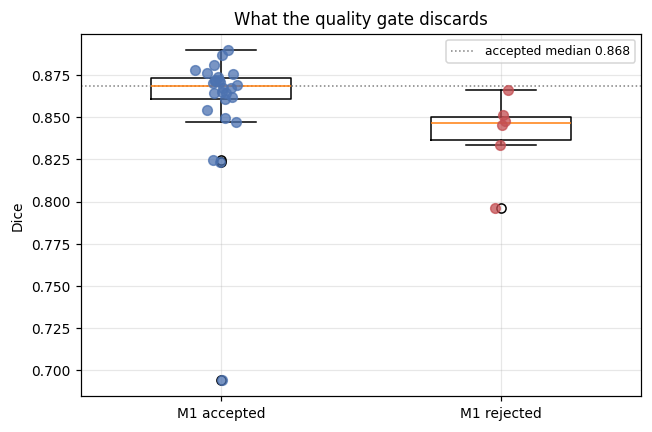

In [5]:
if REJECTED_BY_M1:
    fig, ax = plt.subplots(figsize=(6, 4))
    groups = ["M1 accepted", "M1 rejected"]
    ax.boxplot([graded.loc[graded["gate"] == g, "dice"] for g in groups], labels=groups,
               widths=0.5)
    for index, group in enumerate(groups, start=1):
        values = graded.loc[graded["gate"] == group, "dice"]
        ax.scatter(np.random.default_rng(0).normal(index, 0.04, len(values)), values,
                   alpha=0.75, s=40, zorder=3,
                   color="#4C72B0" if group == "M1 accepted" else "#C44E52")
    ax.axhline(accepted["dice"].median(), color="grey", ls=":", lw=1,
               label=f"accepted median {accepted['dice'].median():.3f}")
    ax.set(ylabel="Dice", title="What the quality gate discards")
    ax.legend(fontsize=8)
    fig.tight_layout()

## 2. Segmentation accuracy

Vessels occupy roughly 2% of the field of view, so **specificity and accuracy sit near 1 for any
prediction** and carry almost no information. Read Dice and IoU; read sensitivity to see which way
the errors fall.

In [6]:
metrics = ["dice", "iou", "sensitivity", "specificity"]

display(ok[metrics].describe().round(4))
display(ok.groupby("disease")[metrics].agg(["mean", "std"]).round(4))

,dice,iou,sensitivity,specificity
count,32.0000,32.0000,32.0000,32.0000
mean,0.8553,0.7487,0.8521,0.9833
std,0.0354,0.0496,0.0617,0.0058
min,0.6943,0.5318,0.6041,0.9682
25%,0.8489,0.7375,0.8381,0.9792
50%,0.8656,0.7630,0.8610,0.9831
75%,0.8719,0.7728,0.8932,0.9878
max,0.8896,0.8012,0.9180,0.9945


dice             iou         sensitivity         specificity        
            mean     std    mean     std        mean     std        mean     std
disease                                                                         
amd       0.8735  0.0101  0.7756  0.0158      0.8780  0.0393      0.9837  0.0043
dr        0.8367  0.0595  0.7229  0.0806      0.8020  0.0923      0.9882  0.0053
glaucoma  0.8657  0.0135  0.7634  0.0211      0.8705  0.0272      0.9829  0.0043
normal    0.8452  0.0268  0.7328  0.0396      0.8578  0.0450      0.9783  0.0052

/var/folders/fr/9n81007x72d8q41sk2r0hsfm0000gn/T/ipykernel_47495/3177343376.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([ok.loc[ok["disease"] == d, "dice"] for d in order], labels=order)


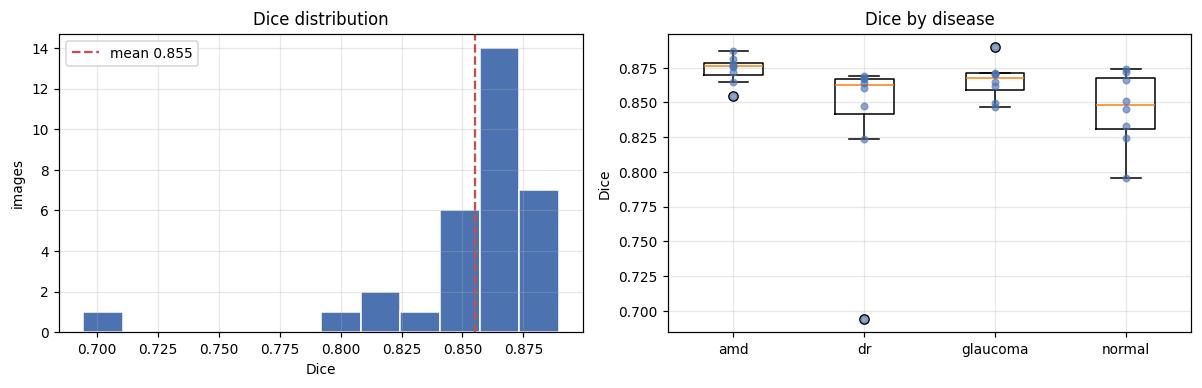

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))

axes[0].hist(ok["dice"], bins=12, color="#4C72B0", edgecolor="white")
axes[0].axvline(ok["dice"].mean(), color="#C44E52", ls="--", label=f"mean {ok['dice'].mean():.3f}")
axes[0].set(xlabel="Dice", ylabel="images", title="Dice distribution")
axes[0].legend()

axes[1].boxplot([ok.loc[ok["disease"] == d, "dice"] for d in order], labels=order)
for index, disease in enumerate(order, start=1):
    values = ok.loc[ok["disease"] == disease, "dice"]
    axes[1].scatter(np.full(len(values), index), values, alpha=0.6, s=18, color="#4C72B0", zorder=3)
axes[1].set(ylabel="Dice", title="Dice by disease")

fig.tight_layout()

correlation of Dice with sensitivity: 0.89
correlation of Dice with specificity: -0.12


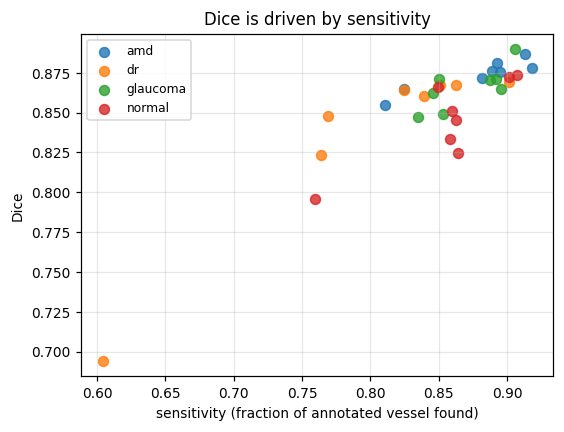

In [8]:
fig, ax = plt.subplots(figsize=(5.2, 4))
for disease in order:
    subset = ok[ok["disease"] == disease]
    ax.scatter(subset["sensitivity"], subset["dice"], label=disease, s=42, alpha=0.8)
ax.set(xlabel="sensitivity (fraction of annotated vessel found)", ylabel="Dice",
       title="Dice is driven by sensitivity")
ax.legend(fontsize=8)
fig.tight_layout()

print("correlation of Dice with sensitivity:", round(ok["dice"].corr(ok["sensitivity"]), 3))
print("correlation of Dice with specificity:", round(ok["dice"].corr(ok["specificity"]), 3))

## 3. Feature agreement

For each feature, predicted against ground truth. Definitions live in `benchmark/agreement.py`,
which is unit-tested — ICC in particular against hand-computed ANOVA values.

- **bias** / **rel_bias_%** — mean signed difference, absolute and as a percentage of the truth's
  mean. A systematic offset, correctable by calibration if it is stable.
- **MAE** / **MAPE_%** — mean absolute error, in the feature's own units and as a percentage.
- **Pearson r** — linear association. Deliberately blind to bias: a constant offset still scores
  1.0. **Spearman** — rank association, which is what matters if the feature orders patients.
- **ICC(2,1)** — intraclass correlation, two-way random effects, absolute agreement, single
  measurement. Unlike Pearson it *charges for systematic bias*, so it is the honest headline
  number. Bands: <0.5 poor, 0.5–0.75 moderate, 0.75–0.9 good, >0.9 excellent. Bootstrap 95%
  intervals are shown because n is small.
- **Bland–Altman limits** — mean difference ± 1.96 SD.

The gap between Pearson and ICC is the interesting column: where Pearson is high and ICC much
lower, the prediction tracks the truth but is offset from it.

In [9]:
agreement = agreement_table(ok, FEATURES, interval=True)

display(
    agreement[
        ["n", "gt_mean", "pred_mean", "bias", "rel_bias_%", "MAE", "MAPE_%",
         "pearson_r", "spearman_r", "ICC21", "ICC_lo", "ICC_hi", "ICC_reading"]
    ].round(3)
)

,n,gt_mean,pred_mean,bias,rel_bias_%,MAE,MAPE_%,pearson_r,spearman_r,ICC21,ICC_lo,ICC_hi,ICC_reading
feature,,,,,,,,,,,,,
Fractal_dimension,32,1.473,1.481,0.008,0.532,0.014,0.929,0.960,0.924,0.921,0.818,0.957,excellent
Vessel_density,32,0.084,0.084,-0.000,-0.035,0.005,6.391,0.924,0.825,0.883,0.712,0.942,good
Average_width,32,115.367,109.209,-6.158,-5.338,6.990,6.004,0.784,0.853,0.641,0.510,0.738,moderate
Distance_tortuosity,32,1.093,1.088,-0.005,-0.456,0.007,0.614,0.686,0.864,0.556,0.299,0.873,moderate
Squared_curvature_tortuosity,32,0.132,0.127,-0.005,-3.559,0.012,8.849,0.577,0.459,0.547,0.217,0.769,moderate
Tortuosity_density,32,0.625,0.607,-0.018,-2.848,0.028,4.435,0.860,0.858,0.828,0.701,0.905,good


In [10]:
# Where does ICC disagree with Pearson? That gap is exactly the systematic bias.
gap = pd.DataFrame(
    {
        "pearson_r": agreement["pearson_r"],
        "ICC21": agreement["ICC21"],
        "pearson_minus_ICC": agreement["pearson_r"] - agreement["ICC21"],
        "rel_bias_%": agreement["rel_bias_%"],
    }
).sort_values("pearson_minus_ICC", ascending=False)

display(gap.round(3))
print("A large gap means the prediction tracks the truth but sits offset from it.")

,pearson_r,ICC21,pearson_minus_ICC,rel_bias_%
feature,,,,
Average_width,0.784,0.641,0.143,-5.338
Distance_tortuosity,0.686,0.556,0.130,-0.456
Vessel_density,0.924,0.883,0.041,-0.035
Fractal_dimension,0.960,0.921,0.039,0.532
Tortuosity_density,0.860,0.828,0.032,-2.848
Squared_curvature_tortuosity,0.577,0.547,0.029,-3.559


A large gap means the prediction tracks the truth but sits offset from it.


In [11]:
# Is the linear agreement statistically distinguishable from zero at this sample size?
for feature in FEATURES:
    pair = ok[[f"{feature}_pred", f"{feature}_gt"]].dropna()
    r, p = stats.pearsonr(pair[f"{feature}_pred"], pair[f"{feature}_gt"])
    rho, p_rho = stats.spearmanr(pair[f"{feature}_pred"], pair[f"{feature}_gt"])
    verdict = "" if p < 0.05 else "   <-- not significant"
    print(f"{feature:32s} n={len(pair):3d}  r={r:6.3f} (p={p:.2g})   rho={rho:6.3f} (p={p_rho:.2g}){verdict}")

Fractal_dimension                n= 32  r= 0.960 (p=3.4e-18)   rho= 0.924 (p=4.5e-14)
Vessel_density                   n= 32  r= 0.924 (p=4.4e-14)   rho= 0.825 (p=6.3e-09)
Average_width                    n= 32  r= 0.784 (p=1.1e-07)   rho= 0.853 (p=5.6e-10)
Distance_tortuosity              n= 32  r= 0.686 (p=1.4e-05)   rho= 0.864 (p=1.9e-10)
Squared_curvature_tortuosity     n= 32  r= 0.577 (p=0.00055)   rho= 0.459 (p=0.0082)
Tortuosity_density               n= 32  r= 0.860 (p=2.9e-10)   rho= 0.858 (p=3.6e-10)


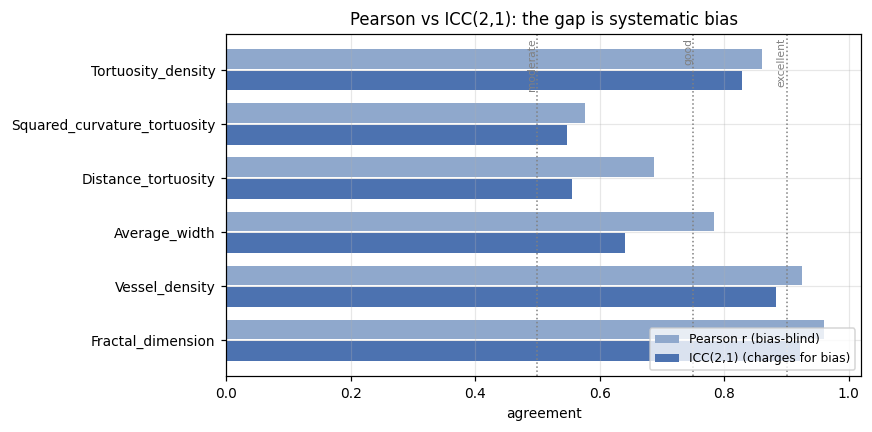

In [12]:
fig, ax = plt.subplots(figsize=(8, 4))
position = np.arange(len(FEATURES))

ax.barh(position + 0.2, agreement.loc[FEATURES, "pearson_r"], height=0.36,
        label="Pearson r (bias-blind)", color="#8FA8CC")
ax.barh(position - 0.2, agreement.loc[FEATURES, "ICC21"], height=0.36,
        label="ICC(2,1) (charges for bias)", color="#4C72B0")

for threshold, name in ((0.9, "excellent"), (0.75, "good"), (0.5, "moderate")):
    ax.axvline(threshold, color="grey", ls=":", lw=1)
    ax.text(threshold, len(FEATURES) - 0.4, name, fontsize=7, rotation=90,
            va="top", ha="right", color="grey")

ax.set(yticks=position, yticklabels=FEATURES, xlabel="agreement", xlim=(0, 1.02),
       title="Pearson vs ICC(2,1): the gap is systematic bias")
ax.legend(fontsize=8, loc="lower right")
fig.tight_layout()

### Does any single image carry the result?

At this sample size one extreme value can manufacture a correlation. Leave-one-out on the ICC finds
it: if dropping a single image moves ICC by more than about 0.15, the agreement is that image's
doing, not the model's.

This is not hypothetical — in the vessel-only run `Squared_curvature_tortuosity` scores ICC 0.544
until one 13x outlier is removed, whereupon it collapses to 0.144. Spearman, being rank-based, is
immune to leverage and stays low throughout, which is why both are reported.

In [13]:
rows = []
for feature in FEATURES:
    pair = ok[["key", f"{feature}_pred", f"{feature}_gt"]].dropna()
    predicted = pair[f"{feature}_pred"].to_numpy()
    reference = pair[f"{feature}_gt"].to_numpy()
    full = icc21(predicted, reference)

    worst_key, worst_icc = None, full
    for position in range(len(pair)):
        keep = np.arange(len(pair)) != position
        without = icc21(predicted[keep], reference[keep])
        if abs(without - full) > abs(worst_icc - full):
            worst_key, worst_icc = pair["key"].iloc[position], without

    rows.append(
        {
            "feature": feature,
            "ICC_all": full,
            "most_influential_image": worst_key,
            "ICC_without_it": worst_icc,
            "swing": worst_icc - full,
            "fragile": abs(worst_icc - full) > 0.15,
        }
    )

leverage = pd.DataFrame(rows).set_index("feature")
display(leverage.round(3))

fragile = leverage[leverage["fragile"]]
if len(fragile):
    print("Leverage-dependent — do not read the ICC point estimate alone:")
    for feature, row in fragile.iterrows():
        print(f"  {feature}: {row['ICC_all']:.3f} -> {row['ICC_without_it']:.3f} "
              f"without {row['most_influential_image']}")
else:
    print("No single image moves any ICC by more than 0.15.")

,ICC_all,most_influential_image,ICC_without_it,swing,fragile
feature,,,,,
Fractal_dimension,0.921,test_52_D,0.880,-0.042,False
Vessel_density,0.883,test_52_D,0.822,-0.060,False
Average_width,0.641,test_67_D,0.671,0.030,False
Distance_tortuosity,0.556,test_167_N,0.778,0.222,True
Squared_curvature_tortuosity,0.547,test_118_G,0.448,-0.099,False
Tortuosity_density,0.828,test_67_D,0.781,-0.047,False


Leverage-dependent — do not read the ICC point estimate alone:
  Distance_tortuosity: 0.556 -> 0.778 without test_167_N


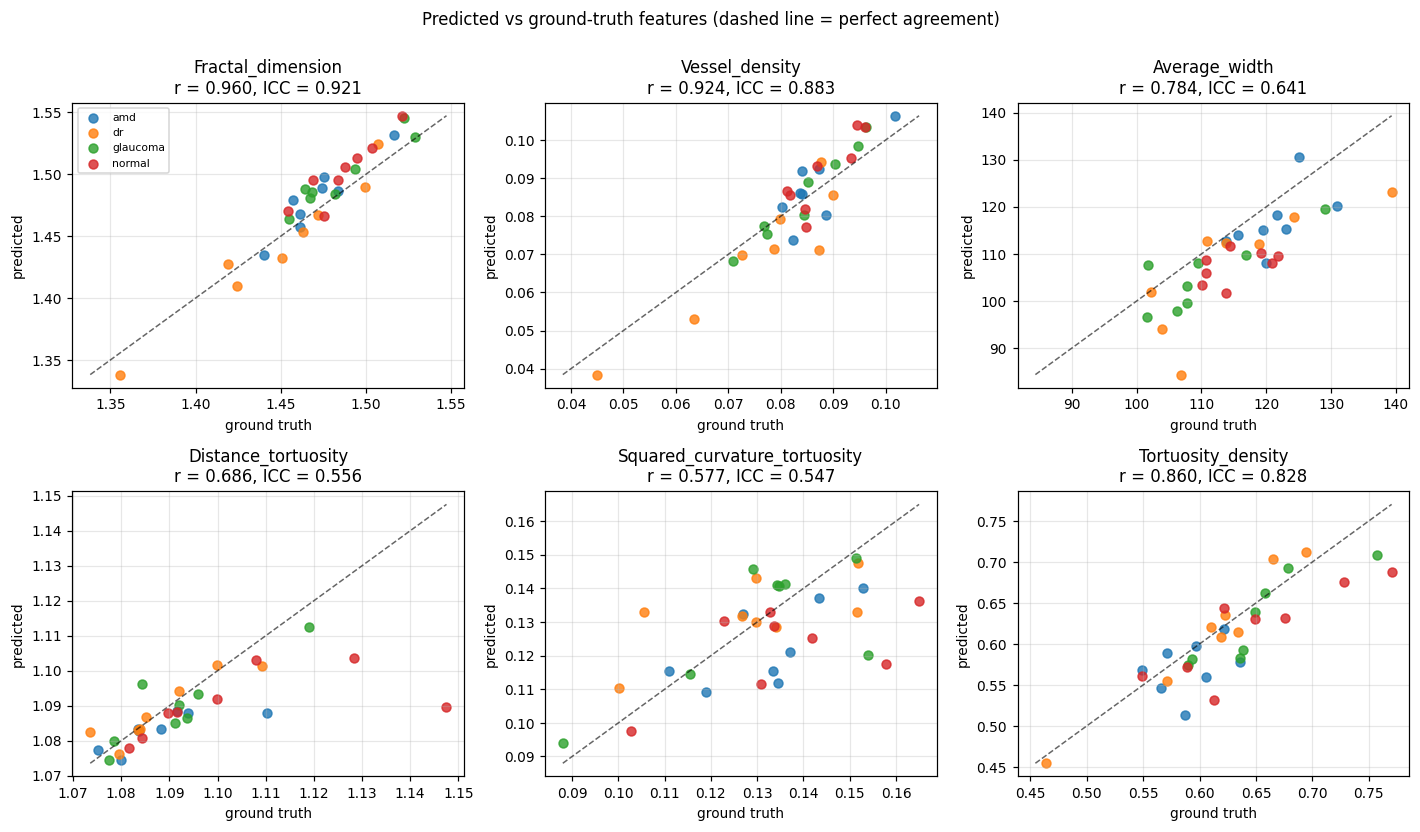

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(13, 7.5))

for ax, feature in zip(axes.ravel(), FEATURES):
    pair = ok[[f"{feature}_pred", f"{feature}_gt", "disease"]].dropna()
    for disease in order:
        subset = pair[pair["disease"] == disease]
        ax.scatter(subset[f"{feature}_gt"], subset[f"{feature}_pred"], label=disease, s=34, alpha=0.8)

    combined_values = pd.concat([pair[f"{feature}_gt"], pair[f"{feature}_pred"]])
    limits = [combined_values.min(), combined_values.max()]
    ax.plot(limits, limits, "k--", lw=1, alpha=0.6)
    r = pair[f"{feature}_pred"].corr(pair[f"{feature}_gt"])
    ax.set(xlabel="ground truth", ylabel="predicted",
           title=f"{feature}\nr = {r:.3f}, ICC = {agreement.loc[feature, 'ICC21']:.3f}")

axes[0, 0].legend(fontsize=7)
fig.suptitle("Predicted vs ground-truth features (dashed line = perfect agreement)", y=1.0)
fig.tight_layout()

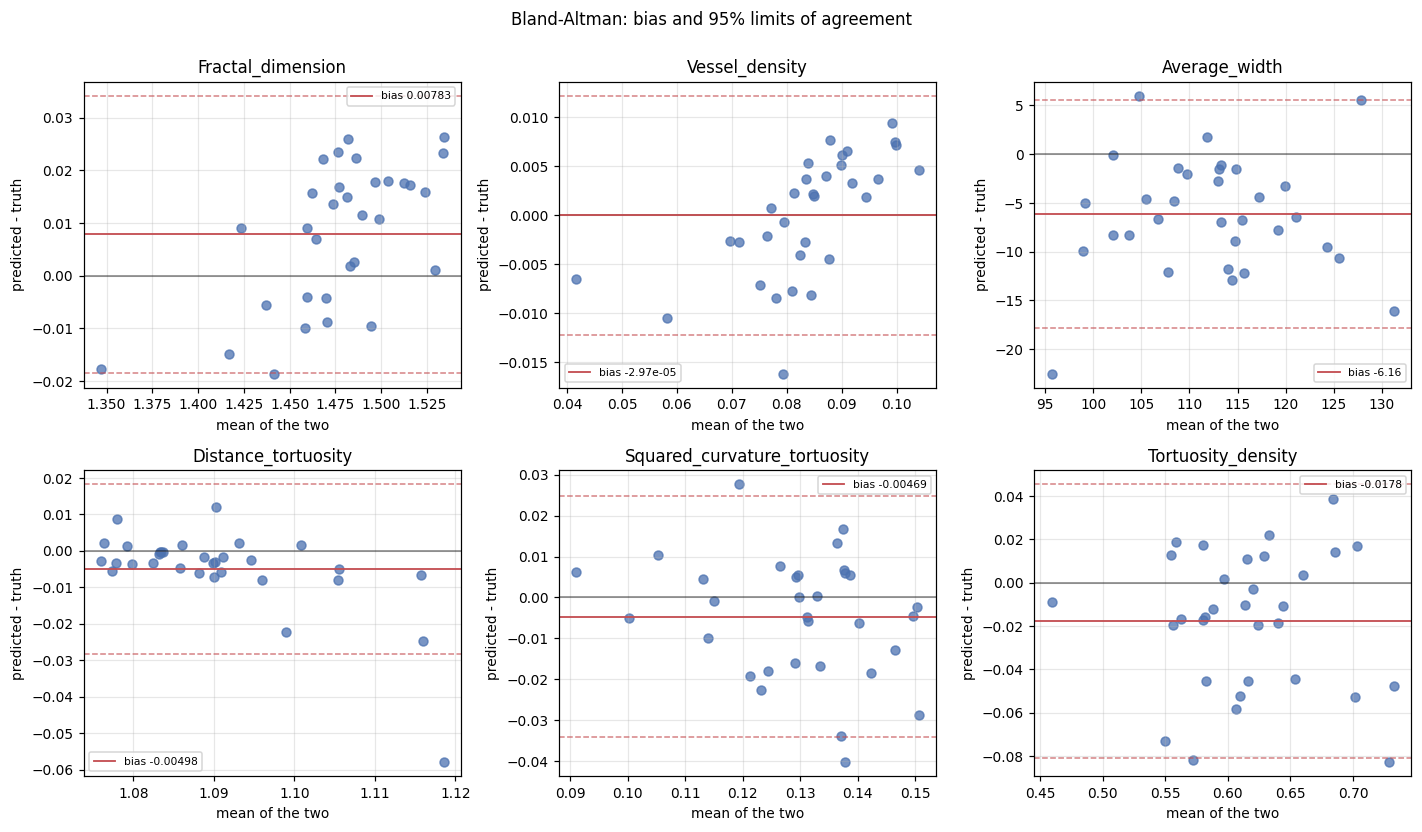

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(13, 7.5))

for ax, feature in zip(axes.ravel(), FEATURES):
    pair = ok[[f"{feature}_pred", f"{feature}_gt"]].dropna()
    mean = (pair[f"{feature}_pred"] + pair[f"{feature}_gt"]) / 2
    difference = pair[f"{feature}_pred"] - pair[f"{feature}_gt"]

    ax.scatter(mean, difference, s=34, alpha=0.75, color="#4C72B0")
    ax.axhline(0, color="k", lw=1, alpha=0.5)
    ax.axhline(difference.mean(), color="#C44E52", lw=1.2, label=f"bias {difference.mean():.3g}")
    for limit in (difference.mean() - 1.96 * difference.std(), difference.mean() + 1.96 * difference.std()):
        ax.axhline(limit, color="#C44E52", ls="--", lw=1, alpha=0.7)
    ax.set(xlabel="mean of the two", ylabel="predicted - truth", title=feature)
    ax.legend(fontsize=7)

fig.suptitle("Bland-Altman: bias and 95% limits of agreement", y=1.0)
fig.tight_layout()

## 4. Before and after the fixes

Against the pre-fix run: original tracing, a 15 px minimum, and binarisation at 0.5. All three
changes are in play at once, so every number moves — Dice included. There is no control group here,
unlike a change confined to the feature formulas.

In [16]:
if BASELINE_AVAILABLE:
    metric_names = ["dice", "iou", "sensitivity", "specificity"]
    comparison = pd.DataFrame(
        {
            "before": base_scores.query("status == 'ok'")[metric_names].mean(),
            "after": scores.query("status == 'ok'")[metric_names].mean(),
        }
    )
    comparison["change"] = comparison["after"] - comparison["before"]
    display(comparison.round(4))
    print("The binarisation threshold does most of this: lowering it buys sensitivity and pays in")
    print("specificity, and Dice rises because the gain is much larger than the loss.")

,before,after,change
dice,0.8249,0.8553,0.0305
iou,0.7050,0.7487,0.0436
sensitivity,0.7360,0.8521,0.1161
specificity,0.9948,0.9833,-0.0115


The binarisation threshold does most of this: lowering it buys sensitivity and pays in
specificity, and Dice rises because the gain is much larger than the loss.


In [17]:
if BASELINE_AVAILABLE:
    base_agreement = agreement_table(base_ok, FEATURES)
    delta = pd.DataFrame(
        {
            "ICC_before": base_agreement["ICC21"],
            "ICC_after": agreement["ICC21"],
            "ICC_change": agreement["ICC21"] - base_agreement["ICC21"],
            "bias%_before": base_agreement["rel_bias_%"],
            "bias%_after": agreement["rel_bias_%"],
            "MAPE%_before": base_agreement["MAPE_%"],
            "MAPE%_after": agreement["MAPE_%"],
        }
    )
    display(delta.round(3).sort_values("ICC_change", ascending=False))

,ICC_before,ICC_after,ICC_change,bias%_before,bias%_after,MAPE%_before,MAPE%_after
feature,,,,,,,
Vessel_density,0.409,0.883,0.474,-21.421,-0.035,22.052,6.391
Average_width,0.319,0.641,0.321,-12.943,-5.338,12.886,6.004
Fractal_dimension,0.701,0.921,0.220,-2.007,0.532,2.024,0.929
Distance_tortuosity,0.412,0.556,0.144,10.643,-0.456,27.647,0.614
Tortuosity_density,0.757,0.828,0.071,-0.574,-2.848,3.552,4.435
Squared_curvature_tortuosity,0.544,0.547,0.003,10.163,-3.559,90.155,8.849


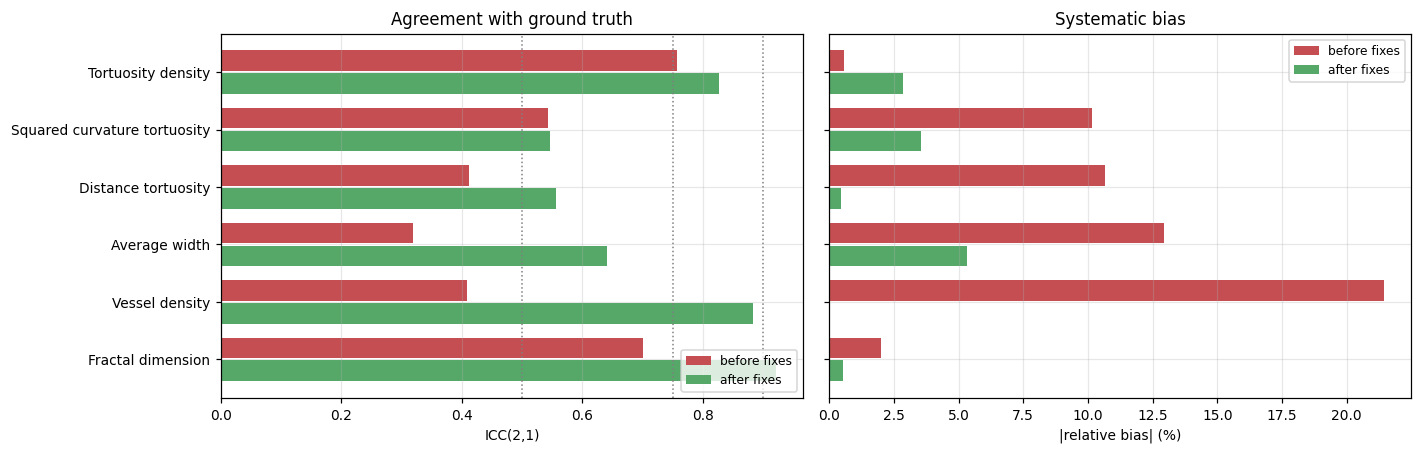

In [18]:
if BASELINE_AVAILABLE:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
    position = np.arange(len(FEATURES))
    labels = [f.replace("_", " ") for f in FEATURES]

    axes[0].barh(position + 0.2, base_agreement.loc[FEATURES, "ICC21"], height=0.36,
                 label="before fixes", color="#C44E52")
    axes[0].barh(position - 0.2, agreement.loc[FEATURES, "ICC21"], height=0.36,
                 label="after fixes", color="#55A868")
    for threshold in (0.5, 0.75, 0.9):
        axes[0].axvline(threshold, color="grey", ls=":", lw=1)
    axes[0].set(yticks=position, yticklabels=labels, xlabel="ICC(2,1)",
                title="Agreement with ground truth")
    axes[0].legend(fontsize=8, loc="lower right")

    axes[1].barh(position + 0.2, base_agreement.loc[FEATURES, "rel_bias_%"].abs(), height=0.36,
                 label="before fixes", color="#C44E52")
    axes[1].barh(position - 0.2, agreement.loc[FEATURES, "rel_bias_%"].abs(), height=0.36,
                 label="after fixes", color="#55A868")
    axes[1].set(yticks=position, yticklabels=["" for _ in FEATURES], xlabel="|relative bias| (%)",
                title="Systematic bias")
    axes[1].legend(fontsize=8)
    fig.tight_layout()

### Is 0.2 the right threshold?

M2 saves the averaged sigmoid map (`binary_vessel/resize/`), so the threshold can be swept without
re-running the network — re-binarise, re-apply `remove_small_objects(30)`, re-score. That makes the
choice checkable rather than assumed.

,threshold,dice,iou,sensitivity,specificity
0,0.05,0.8131,0.6862,0.9465,0.9539
1,0.10,0.8376,0.7218,0.9028,0.9696
2,0.15,0.8536,0.7458,0.8773,0.9786
3,0.20,0.8554,0.7488,0.8530,0.9832
4,0.25,0.8544,0.7476,0.8318,0.9864
5,0.30,0.8512,0.7429,0.8108,0.9890
6,0.35,0.8460,0.7354,0.7916,0.9908
7,0.40,0.8406,0.7276,0.7741,0.9923
8,0.50,0.8249,0.7050,0.7360,0.9948
9,0.60,0.8047,0.6770,0.6971,0.9965


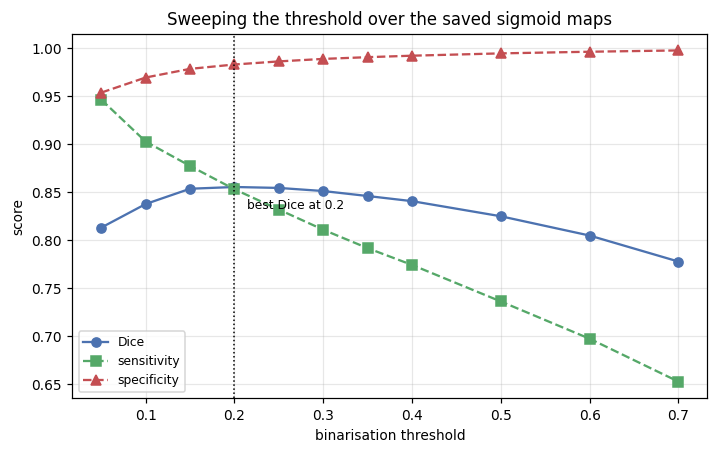

In [19]:
if SWEEP_PATH.is_file():
    sweep = pd.read_csv(SWEEP_PATH)
    display(sweep.round(4))

    fig, ax = plt.subplots(figsize=(6.6, 4.2))
    ax.plot(sweep["threshold"], sweep["dice"], "o-", label="Dice", color="#4C72B0")
    ax.plot(sweep["threshold"], sweep["sensitivity"], "s--", label="sensitivity", color="#55A868")
    ax.plot(sweep["threshold"], sweep["specificity"], "^--", label="specificity", color="#C44E52")

    best = sweep.loc[sweep["dice"].idxmax(), "threshold"]
    ax.axvline(best, color="k", ls=":", lw=1)
    ax.annotate(f"best Dice at {best}", (best, sweep["dice"].max()), fontsize=8,
                xytext=(8, -14), textcoords="offset points")
    ax.set(xlabel="binarisation threshold", ylabel="score",
           title="Sweeping the threshold over the saved sigmoid maps")
    ax.legend(fontsize=8)
    fig.tight_layout()
else:
    print("no sweep on disk; see docs/fixes.md")

## 4. Does Dice predict feature error?

If it does, Dice is a usable proxy for feature trustworthiness on unlabelled data — the only
situation that matters in practice, since you will not have annotations. If it does not, a good Dice
is no guarantee that the reported morphometry is right.

In [20]:
rows = []
for feature in FEATURES:
    pair = ok[[f"{feature}_pred", f"{feature}_gt", "dice", "sensitivity"]].dropna()
    relative_error = (pair[f"{feature}_pred"] - pair[f"{feature}_gt"]).abs() / pair[f"{feature}_gt"].abs()
    rows.append(
        {
            "feature": feature,
            "corr(dice, |rel err|)": pair["dice"].corr(relative_error),
            "corr(sens, |rel err|)": pair["sensitivity"].corr(relative_error),
            "median_|rel err|_%": 100 * relative_error.median(),
        }
    )

proxy_table = pd.DataFrame(rows).set_index("feature")
display(proxy_table.round(3))

,"corr(dice, |rel err|)","corr(sens, |rel err|)",median_|rel err|_%
feature,,,
Fractal_dimension,0.005,0.154,1.030
Vessel_density,-0.559,-0.634,4.867
Average_width,-0.720,-0.818,5.789
Distance_tortuosity,-0.373,-0.271,0.319
Squared_curvature_tortuosity,-0.626,-0.455,6.592
Tortuosity_density,-0.089,-0.011,2.990


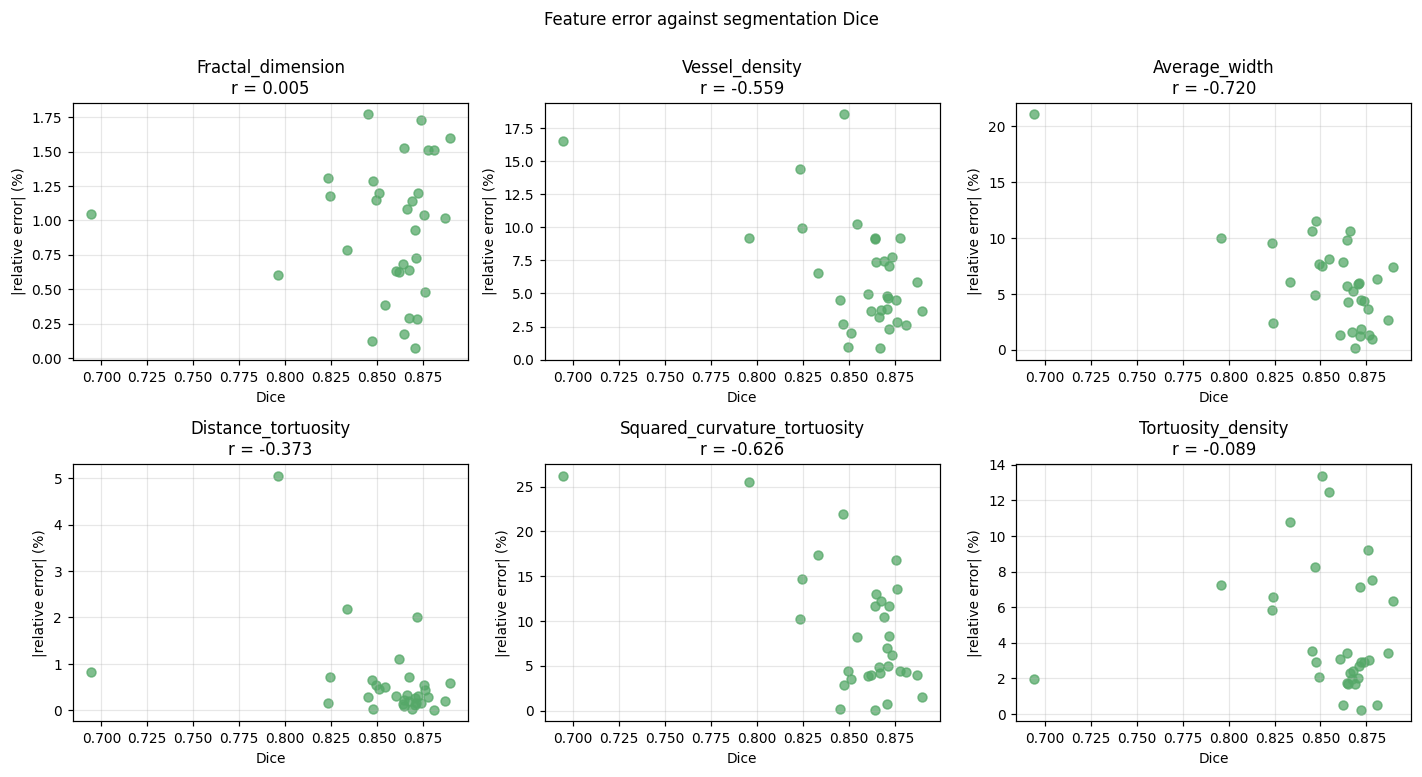

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(13, 7))

for ax, feature in zip(axes.ravel(), FEATURES):
    pair = ok[[f"{feature}_pred", f"{feature}_gt", "dice"]].dropna()
    relative_error = 100 * (pair[f"{feature}_pred"] - pair[f"{feature}_gt"]).abs() / pair[f"{feature}_gt"].abs()
    ax.scatter(pair["dice"], relative_error, s=34, alpha=0.75, color="#55A868")
    ax.set(xlabel="Dice", ylabel="|relative error| (%)",
           title=f"{feature}\nr = {pair['dice'].corr(relative_error):.3f}")

fig.suptitle("Feature error against segmentation Dice", y=1.0)
fig.tight_layout()

## 5. Per-disease agreement

Small groups — read as indicative, not conclusive.

In [22]:
for disease in order:
    subset = ok[ok["disease"] == disease]
    print(f"\n=== {disease}  (n={len(subset)}, mean Dice {subset['dice'].mean():.3f}) ===")
    display(
        agreement_table(subset, FEATURES)[
            ["rel_bias_%", "MAE", "MAPE_%", "pearson_r", "spearman_r", "ICC21"]
        ].round(3)
    )


=== amd  (n=8, mean Dice 0.874) ===


,rel_bias_%,MAE,MAPE_%,pearson_r,spearman_r,ICC21
feature,,,,,,
Fractal_dimension,0.638,0.012,0.801,0.937,0.833,0.862
Vessel_density,1.040,0.005,5.847,0.796,0.571,0.764
Average_width,-3.599,5.756,4.672,0.574,0.810,0.465
Distance_tortuosity,-0.467,0.006,0.510,0.772,0.857,0.529
Squared_curvature_tortuosity,-7.129,0.012,8.913,0.680,0.714,0.548
Tortuosity_density,-3.424,0.030,4.984,0.362,0.405,0.318



=== dr  (n=8, mean Dice 0.837) ===


,rel_bias_%,MAE,MAPE_%,pearson_r,spearman_r,ICC21
feature,,,,,,
Fractal_dimension,-0.421,0.013,0.878,0.978,0.976,0.967
Vessel_density,-6.891,0.007,9.461,0.927,0.905,0.881
Average_width,-6.710,8.151,7.015,0.785,0.810,0.676
Distance_tortuosity,0.026,0.003,0.299,0.916,0.952,0.908
Squared_curvature_tortuosity,2.709,0.011,8.771,0.671,0.500,0.601
Tortuosity_density,0.476,0.017,2.709,0.978,0.881,0.968



=== glaucoma  (n=8, mean Dice 0.866) ===


,rel_bias_%,MAE,MAPE_%,pearson_r,spearman_r,ICC21
feature,,,,,,
Fractal_dimension,0.841,0.012,0.843,0.951,0.810,0.867
Vessel_density,1.478,0.003,3.963,0.979,0.976,0.936
Average_width,-4.322,6.257,5.649,0.828,0.857,0.716
Distance_tortuosity,-0.154,0.005,0.457,0.880,0.738,0.879
Squared_curvature_tortuosity,0.390,0.010,7.196,0.726,0.476,0.749
Tortuosity_density,-3.216,0.025,3.843,0.890,1.000,0.837



=== normal  (n=8, mean Dice 0.845) ===


,rel_bias_%,MAE,MAPE_%,pearson_r,spearman_r,ICC21
feature,,,,,,
Fractal_dimension,1.045,0.018,1.192,0.920,0.929,0.746
Vessel_density,3.344,0.006,6.294,0.851,0.738,0.726
Average_width,-6.767,7.795,6.679,0.474,0.548,0.168
Distance_tortuosity,-1.219,0.013,1.190,0.574,0.857,0.324
Squared_curvature_tortuosity,-9.810,0.015,10.515,0.587,0.452,0.426
Tortuosity_density,-5.075,0.042,6.204,0.844,0.857,0.738


## 6. Informational strength of each feature

Agreement is only half the question. A feature also has to **vary between eyes**, or it cannot
separate them however precisely it is measured.

Informational strength is `IQR / median` over the **ground truth** — a robust, unit-free measure of
how much spread the feature has in the population. It says nothing about AutoMorph; it is a property
of the feature and this cohort, so it is computed over every annotated image, not only the ones that
produced a prediction.

In [23]:
strength = informational_strength(truth_all, FEATURES).sort_values(
    "gt_IQR_over_median", ascending=False
)
display(strength.round(4))

,n,gt_median,gt_IQR,gt_IQR_over_median
feature,,,,
Squared_curvature_tortuosity,32,0.1335,0.0165,0.1234
Average_width,32,114.1119,11.9892,0.1051
Vessel_density,32,0.0845,0.0088,0.1041
Tortuosity_density,32,0.6217,0.0621,0.0999
Fractal_dimension,32,1.4728,0.0336,0.0228
Distance_tortuosity,32,1.0904,0.0134,0.0123


### Spread against noise

`spread_to_noise` is the ground-truth IQR divided by the standard deviation of the prediction error,
with systematic bias excluded — a constant offset does not stop a feature separating one eye from
another, but random scatter does.

Below about 1 the measurement noise covers the feature's whole interquartile range: even a
"low-error" feature cannot rank eyes if its spread is narrower than its error.

In [24]:
combined = discriminability(agreement, informational_strength(ok, FEATURES))
combined["MAPE_%"] = agreement["MAPE_%"]
combined["ICC21"] = agreement["ICC21"]
display(combined.sort_values("spread_to_noise", ascending=False).round(3))

,gt_IQR_over_median,error_sd,spread_to_noise,MAPE_%,ICC21
feature,,,,,
Fractal_dimension,0.023,0.013,2.500,0.929,0.921
Average_width,0.105,5.963,2.011,6.004,0.641
Tortuosity_density,0.100,0.032,1.927,4.435,0.828
Vessel_density,0.104,0.006,1.408,6.391,0.883
Distance_tortuosity,0.012,0.012,1.129,0.614,0.556
Squared_curvature_tortuosity,0.123,0.015,1.098,8.849,0.547


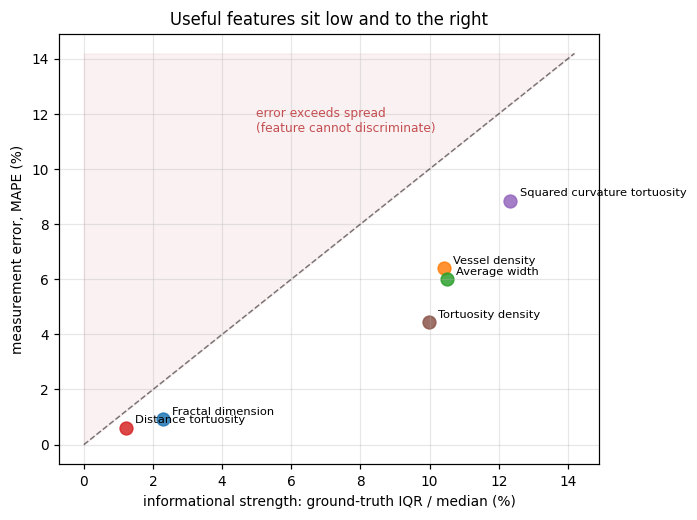

In [25]:
fig, ax = plt.subplots(figsize=(6.4, 4.8))

for feature in FEATURES:
    ax.scatter(combined.loc[feature, "gt_IQR_over_median"] * 100,
               agreement.loc[feature, "MAPE_%"], s=70, alpha=0.85)
    ax.annotate(feature.replace("_", " "),
                (combined.loc[feature, "gt_IQR_over_median"] * 100, agreement.loc[feature, "MAPE_%"]),
                fontsize=7.5, xytext=(6, 3), textcoords="offset points")

ceiling = max(combined["gt_IQR_over_median"].max() * 100, agreement["MAPE_%"].max()) * 1.15
ax.plot([0, ceiling], [0, ceiling], "k--", lw=1, alpha=0.5)
ax.fill_between([0, ceiling], [0, ceiling], ceiling, color="#C44E52", alpha=0.07)
ax.text(ceiling * 0.35, ceiling * 0.8, "error exceeds spread\n(feature cannot discriminate)",
        fontsize=8, color="#C44E52")

ax.set(xlabel="informational strength: ground-truth IQR / median (%)",
       ylabel="measurement error, MAPE (%)",
       title="Useful features sit low and to the right")
fig.tight_layout()

## 7. Verdict per feature

Generated from the numbers above rather than hand-written, so it cannot drift out of sync with the
data. The thresholds are judgement calls, stated explicitly in the code so they can be argued with.
A feature whose ICC depends on one image is judged on the leave-one-out value, not the headline.

In [26]:
def verdict(feature):
    icc = agreement.loc[feature, "ICC21"]
    if leverage.loc[feature, "fragile"]:
        icc = leverage.loc[feature, "ICC_without_it"]        # judge on the robust value
    if not np.isfinite(icc):
        # icc21 returns NaN for a feature that is constant across subjects: there is no
        # between-subject variance for an agreement coefficient to be a ratio of.
        return "unusable - constant across eyes, no agreement is definable"
    spearman = agreement.loc[feature, "spearman_r"]
    mape = agreement.loc[feature, "MAPE_%"]
    bias = abs(agreement.loc[feature, "rel_bias_%"])
    ratio = combined.loc[feature, "spread_to_noise"]

    if icc < 0.5 and spearman < 0.5:
        return "unusable - no agreement with truth"
    if ratio < 1.0:
        return "error covers the population spread - cannot rank eyes"
    if bias > 10:
        return "rank-usable, biased - calibrate before quoting absolutes"
    if mape < 5 and icc >= 0.75:
        return "reliable"
    return "usable with care"


verdicts = pd.DataFrame(
    {
        "rel_bias_%": agreement["rel_bias_%"],
        "MAE": agreement["MAE"],
        "MAPE_%": agreement["MAPE_%"],
        "pearson_r": agreement["pearson_r"],
        "spearman_r": agreement["spearman_r"],
        "ICC21": agreement["ICC21"],
        "ICC_robust": leverage["ICC_without_it"].where(leverage["fragile"], agreement["ICC21"]),
        "gt_IQR_over_median": combined["gt_IQR_over_median"],
        "spread_to_noise": combined["spread_to_noise"],
    }
)
verdicts["verdict"] = [verdict(feature) for feature in verdicts.index]
display(verdicts.round(3).sort_values("ICC_robust", ascending=False))

,rel_bias_%,MAE,MAPE_%,pearson_r,spearman_r,ICC21,ICC_robust,gt_IQR_over_median,spread_to_noise,verdict
feature,,,,,,,,,,
Fractal_dimension,0.532,0.014,0.929,0.960,0.924,0.921,0.921,0.023,2.500,reliable
Vessel_density,-0.035,0.005,6.391,0.924,0.825,0.883,0.883,0.104,1.408,usable with care
Tortuosity_density,-2.848,0.028,4.435,0.860,0.858,0.828,0.828,0.100,1.927,reliable
Distance_tortuosity,-0.456,0.007,0.614,0.686,0.864,0.556,0.778,0.012,1.129,reliable
Average_width,-5.338,6.990,6.004,0.784,0.853,0.641,0.641,0.105,2.011,usable with care
Squared_curvature_tortuosity,-3.559,0.012,8.849,0.577,0.459,0.547,0.547,0.123,1.098,usable with care


## 8. Conclusions

Generated from the run below, so the prose cannot drift from the numbers.

In [27]:
lines = [f"RUN: {RUN_LABEL}", ""]

lines += [
    "SEGMENTATION",
    f"  Dice {ok['dice'].mean():.3f}, sensitivity {ok['sensitivity'].mean():.3f}, "
    f"specificity {ok['specificity'].mean():.3f} over n={len(ok)}.",
    f"  The model under-segments: it misses ~{100 * (1 - ok['sensitivity'].mean()):.0f}% of annotated"
    " vessel and invents almost none.",
    f"  Dice correlates with sensitivity at r={ok['dice'].corr(ok['sensitivity']):.3f}, so here Dice"
    " is largely a restatement of sensitivity.",
    "",
    "QUALITY GATE",
]

if GATE_ENFORCED:
    dropped = int((scores["status"] != "ok").sum())
    lines += [
        f"  Enforced. It rejected {dropped} of {len(scores)} FIVES quality-3 images; rejection is"
        " silent and total.",
        "  Feature results below are conditioned on the survivors, so they are optimistic.",
    ]
elif REJECTED_BY_M1:
    inside = ok[ok["key"].isin(REJECTED_BY_M1)]["dice"]
    outside = ok[~ok["key"].isin(REJECTED_BY_M1)]["dice"]
    _, p_gate = stats.mannwhitneyu(inside, outside)
    lines += [
        f"  Bypassed; all {len(ok)} images segmented.",
        f"  The {len(inside)} images M1 would have rejected score Dice {inside.mean():.3f} against"
        f" {outside.mean():.3f} for the rest (Mann-Whitney p={p_gate:.3f}).",
        f"  Discarding them would raise mean Dice by {outside.mean() - ok['dice'].mean():+.4f} while"
        f" losing {100 * len(inside) / len(ok):.0f}% of the cohort.",
    ]
else:
    lines += [f"  Bypassed; all {len(ok)} images segmented."]

lines += ["", "FEATURE AGREEMENT"]
for feature in verdicts.sort_values("ICC_robust", ascending=False).index:
    row = verdicts.loc[feature]
    note = "  (leverage-adjusted)" if leverage.loc[feature, "fragile"] else ""
    lines.append(
        f"  {feature:30s} ICC={row['ICC_robust']:5.2f} ({icc_label(row['ICC_robust']):9s})"
        f" bias={row['rel_bias_%']:+6.1f}%  MAPE={row['MAPE_%']:5.1f}%"
        f"  spread/noise={row['spread_to_noise']:4.1f}{note}"
    )
    lines.append(f"      -> {row['verdict']}")

proxy = proxy_table["corr(dice, |rel err|)"].sort_values()
lines += [
    "",
    "IS DICE A USABLE PROXY?",
    "  In production there are no annotations, so Dice is the only handle available.",
    f"  It tracks feature error well for: {', '.join(proxy[proxy < -0.5].index) or 'nothing'}",
    f"  It is uninformative about:       {', '.join(proxy[proxy > -0.3].index) or 'nothing'}",
]

print("\n".join(lines))

RUN: M0 + M2 vessel only, gate bypassed, all fixes applied

SEGMENTATION
  Dice 0.855, sensitivity 0.852, specificity 0.983 over n=32.
  The model under-segments: it misses ~15% of annotated vessel and invents almost none.
  Dice correlates with sensitivity at r=0.890, so here Dice is largely a restatement of sensitivity.

QUALITY GATE
  Bypassed; all 32 images segmented.
  The 6 images M1 would have rejected score Dice 0.840 against 0.859 for the rest (Mann-Whitney p=0.012).
  Discarding them would raise mean Dice by +0.0036 while losing 19% of the cohort.

FEATURE AGREEMENT
  Fractal_dimension              ICC= 0.92 (excellent) bias=  +0.5%  MAPE=  0.9%  spread/noise= 2.5
      -> reliable
  Vessel_density                 ICC= 0.88 (good     ) bias=  -0.0%  MAPE=  6.4%  spread/noise= 1.4
      -> usable with care
  Tortuosity_density             ICC= 0.83 (good     ) bias=  -2.8%  MAPE=  4.4%  spread/noise= 1.9
      -> reliable
  Distance_tortuosity            ICC= 0.78 (good     ) 

In [28]:
# Save the tables next to the rest of this run's output.
agreement.round(6).to_csv(RESULTS / "feature_agreement.csv")
verdicts.round(6).to_csv(RESULTS / "feature_verdicts.csv")
strength.round(6).to_csv(RESULTS / "feature_informational_strength.csv")
leverage.to_csv(RESULTS / "feature_leverage.csv")
proxy_table.round(6).to_csv(RESULTS / "dice_as_proxy.csv")
Path(RESULTS / "conclusions.txt").write_text("\n".join(lines) + "\n")
print(f"wrote agreement, verdicts, informational strength, leverage, proxy and conclusions to {RESULTS}")

wrote agreement, verdicts, informational strength, leverage, proxy and conclusions to /Users/staskh/Sandbox/AutoMorph/benchmark/results/M2_vessels_thr02_mean
